## [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/)
## Cod. 202321287
# IMEC2540EVA3


In [1]:
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex, atan2, pprint, init_printing, Derivative, sqrt, diff, Eq, tan, integrate, lambdify, ln
from sympy.physics.vector import dynamicsymbols, init_vprinting, ReferenceFrame, cross, Point, dot
from numpy import deg2rad, linspace, gradient
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.integrate import solve_ivp
from sympy import factor, pi
init_vprinting(use_latex='mathjax')


# Ej1 (1 punto) Sistema masa-resorte amortiguador
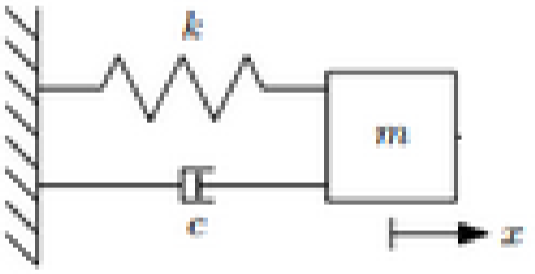

# Ej1a
Para el sistema masa-resorte-amortiguador escriba la ecuación diferencial que modela
el sistema usando las variables k,c,m y luego usando las variables zeta y omega_n.

In [2]:
# Parámetros simbólicos
m, k, c = symbols('m k c', positive=True)

# Variable dependiente
x = dynamicsymbols('x')

# Derivadas correctas con SymPy physics.vector
dx = x.diff()
ddx = x.diff(dynamicsymbols._t, 2)

# Ecuación del sistema masa-resorte-amortiguador:
eq = Eq(m*ddx + c*dx + k*x, 0)

# Frecuencia natural no amortiguada
wn = sqrt(k/m)

# Razón de amortiguamiento
zeta = c / (2*sqrt(m*k))

# Frecuencia amortiguada
wd = wn*sqrt(1 - zeta**2)

# Periodos
Tn = 2*pi/wn      # periodo natural
Td = 2*pi/wd      # periodo amortiguado

# Resultados
print("Ecuación del sistema:")
display(eq)

print("\nFrecuencia natural wn:")
display(wn)

print("\nRazón de amortiguamiento zeta:")
display(zeta)

print("\nFrecuencia amortiguada wd:")
display(wd)

print("\nPeriodo natural Tn:")
display(Tn)

print("\nPeriodo amortiguado Td:")
display(Td)

Ecuación del sistema:


c⋅ẋ + k⋅x + m⋅ẍ = 0


Frecuencia natural wn:


√k
──
√m


Razón de amortiguamiento zeta:


...

        _____________
       ╱     2       
      ╱     c        
√k⋅  ╱   - ───── + 1 
   ╲╱      4⋅k⋅m     
─────────────────────
         √m          


Periodo natural Tn:


2⋅π⋅√m
──────
  √k  


Periodo amortiguado Td:


       2⋅π⋅√m        
─────────────────────
        _____________
       ╱     2       
      ╱     c        
√k⋅  ╱   - ───── + 1 
   ╲╱      4⋅k⋅m     

# Ej1b
Sabiendo que k=1.5kN/m, c=10Ns/m y m=2kg. Calcule los valores de zeta y omega_n

In [3]:
m_val = 2
k_val = 1500
c_val = 10

# frecuencia natural
wn_val = sqrt(k_val/m_val)

# razón de amortiguamiento
zeta_val = c_val / (2*sqrt(m_val*k_val))

display(wn_val.evalf())
display(zeta_val.evalf())


27.3861278752583

0.0912870929175277

# Ej1c
Explique qué le indican los valores numéricos respecto a cómo se mueve el sistema en
su forma libre.

### **Frecuencia natural wn**

Es la velocidad con la que oscilaría la masa si **no hubiera amortiguador**, solo resorte y masa.
Depende únicamente de la rigidez del resorte y la masa.
Si la rigidez aumenta, la frecuencia sube.
Si la masa aumenta, la frecuencia baja.

### **Razón de amortiguamiento zeta**

Compara el amortiguamiento real del sistema con el amortiguamiento crítico.
Describe el tipo de movimiento:

* Si zeta es menor que 1: el sistema oscila, pero se va frenando.
* Si zeta es igual a 1: el sistema no oscila, pero vuelve lo más rápido posible al equilibrio sin vibrar.
* Si zeta es mayor que 1: tampoco oscila, pero tarda más en regresar.

El amortiguador solo modifica la forma en que el sistema pierde energía, no cambia la rigidez o la masa.

### **Frecuencia amortiguada wd**

Es la frecuencia real cuando sí existe amortiguamiento.
Siempre es menor que la frecuencia natural.

### **Periodo natural y amortiguado**

* El periodo natural es el tiempo que tarda una oscilación sin amortiguamiento.
* El periodo amortiguado es un poco mayor porque la vibración es más lenta.


# Ej2 
(1.5 punto) El carrito de masa m=50kg es movido por un yugo escoces de radio
b=10.0cm que gira a velocidad constante. El carrito está acoplado a través de un resorte
k=2.0kN/m y c=2.0Ns/m.

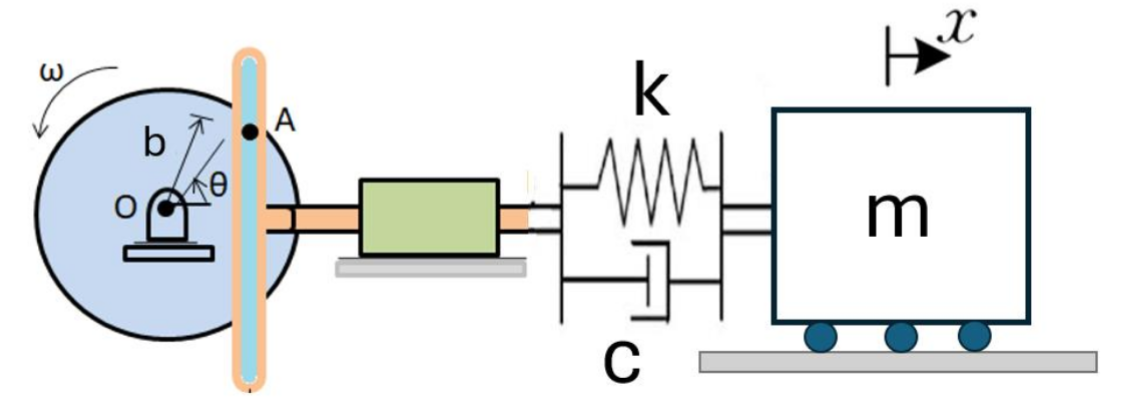

Encuentre la velocidad angular del yugo que produciría el máximo desplazamiento del
carrito y realice una gráfica de este desplazamiento.

In [4]:
# símbolos
t = dynamicsymbols._t
x = dynamicsymbols('x')
omega = symbols('omega', positive=True)
m, b, k, c = symbols('m b k c', positive=True)

# entrada del yugo: posición impuesta en el punto
x_f = b*cos(omega*t)

# ecuación diferencial del sistema: m*x'' + c*x' + k*x = fuerza
# fuerza equivalente por movimiento de base: -m*x_f''
eq = Eq(m*x.diff(t,2) + c*x.diff(t) + k*x, -m*diff(x_f, t, 2))

display(eq)

# suponer solución en régimen permanente:
# x(t) = X*cos(omega*t - phi)
# SymPy: usar forma compleja: x = X*exp(i*omega*t)
X = symbols('X', real=True)

# Fuerza en frecuencia: F = m*b*omega^2
F = m*b*omega**2

# función de transferencia H(iω) = 1 / (k - mω² + i cω)
H = 1 / (k - m*omega**2 + c*omega*1j)

display(H)

# Amplitud = |H| * F
X_w_expr = abs(H) * F

display(X_w_expr.simplify())


                       2         
c⋅ẋ + k⋅x + m⋅ẍ = b⋅m⋅ω ⋅cos(ω⋅t)

         1          
────────────────────
                   2
1.0⋅ⅈ⋅c⋅ω + k - m⋅ω 

                     2                
                b⋅m⋅ω                 
──────────────────────────────────────
   ___________________________________
  ╱      2  2    2          2    2  4 
╲╱  1.0⋅c ⋅ω  + k  - 2⋅k⋅m⋅ω  + m ⋅ω  

6.32461856683866

6.32461856683866

1.00659430808315

15.8114673583763

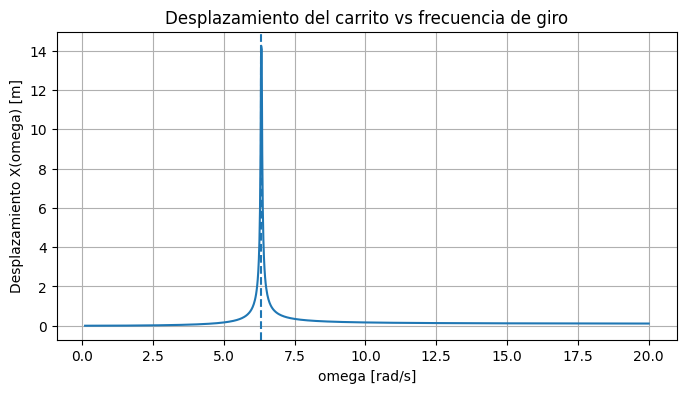

In [5]:
# --- Símbolos ---
omega = symbols('omega', positive=True)

# --- Parámetros ---
m_val = 50
b_val = 0.10
k_val = 2000
c_val = 2

# --- Amplitud de respuesta X(omega) ---
X_w = (m_val*b_val*omega**2) / sqrt((k_val - m_val*omega**2)**2 + (c_val*omega)**2)

# --- Derivada para encontrar omega que maximiza X ---
dX = diff(X_w, omega)

# --- Resolver dX/domega = 0 ---
omega_candidates = solve(Eq(dX, 0), omega)

# --- Seleccionar raíz real y positiva ---
omega_res = [w for w in omega_candidates if w.is_real][0]

# --- Evaluar numéricamente ---
omega_val = omega_res.evalf()
f_val = (omega_val/(2*pi)).evalf()   # en Hz
X_max_val = X_w.subs(omega, omega_res).evalf()

# --- Mostrar resultados ---
display(omega_res)       # expresión simbólica
display(omega_val)       # valor numérico rad/s
display(f_val)           # valor numérico Hz
display(X_max_val)       # amplitud máxima evaluada

# --- Gráfica ---
omega_vals = np.linspace(0.1, 20, 1000)
X_vals = [float(X_w.subs(omega, w)) for w in omega_vals]

plt.figure(figsize=(8,4))
plt.plot(omega_vals, X_vals)
plt.axvline(float(omega_val), linestyle='--')
plt.xlabel("omega [rad/s]")
plt.ylabel("Desplazamiento X(omega) [m]")
plt.title("Desplazamiento del carrito vs frecuencia de giro")
plt.grid(True)
plt.show()


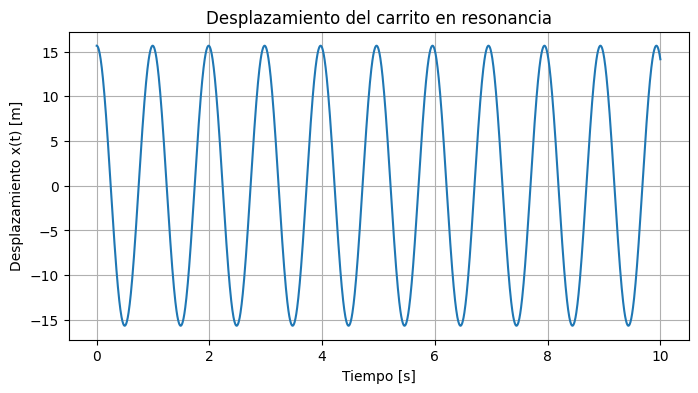

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m_val = 50
b_val = 0.10
k_val = 2000
c_val = 2

omega_val = 6.327513756878439  # rad/s 

X_w = lambda omega: (m_val*b_val*omega**2) / np.sqrt((k_val - m_val*omega**2)**2 + (c_val*omega)**2)
X_max = X_w(omega_val)

t = np.linspace(0, 10, 2000)
x_t = X_max * np.cos(omega_val * t)

# Plot
plt.figure(figsize=(8,4))
plt.plot(t, x_t)
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento x(t) [m]")
plt.title("Desplazamiento del carrito en resonancia")
plt.grid(True)
plt.show()


# Ej3 (1 punto) 
A nuestro clásico sistema dinámico masa-resorte-amortiguador, le agregamos un
péndulo elástico con constante de elasticidad ke y longitud en equilibrio l1.
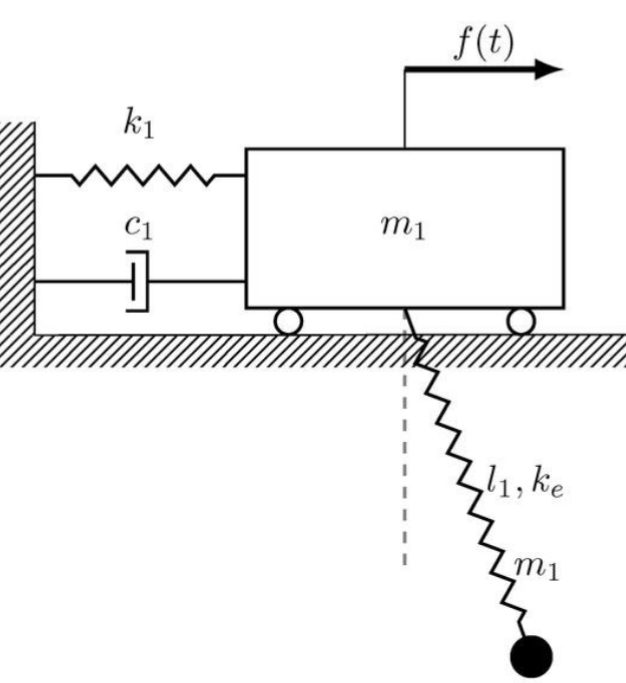

### Ej3a Escriba las ecuaciones que permiten modelar el sistema

Este sistema se puede ver como un mass dampener comunmente usado para reducir oscilaciones en edificios debido a vientos cortantes fuertes:
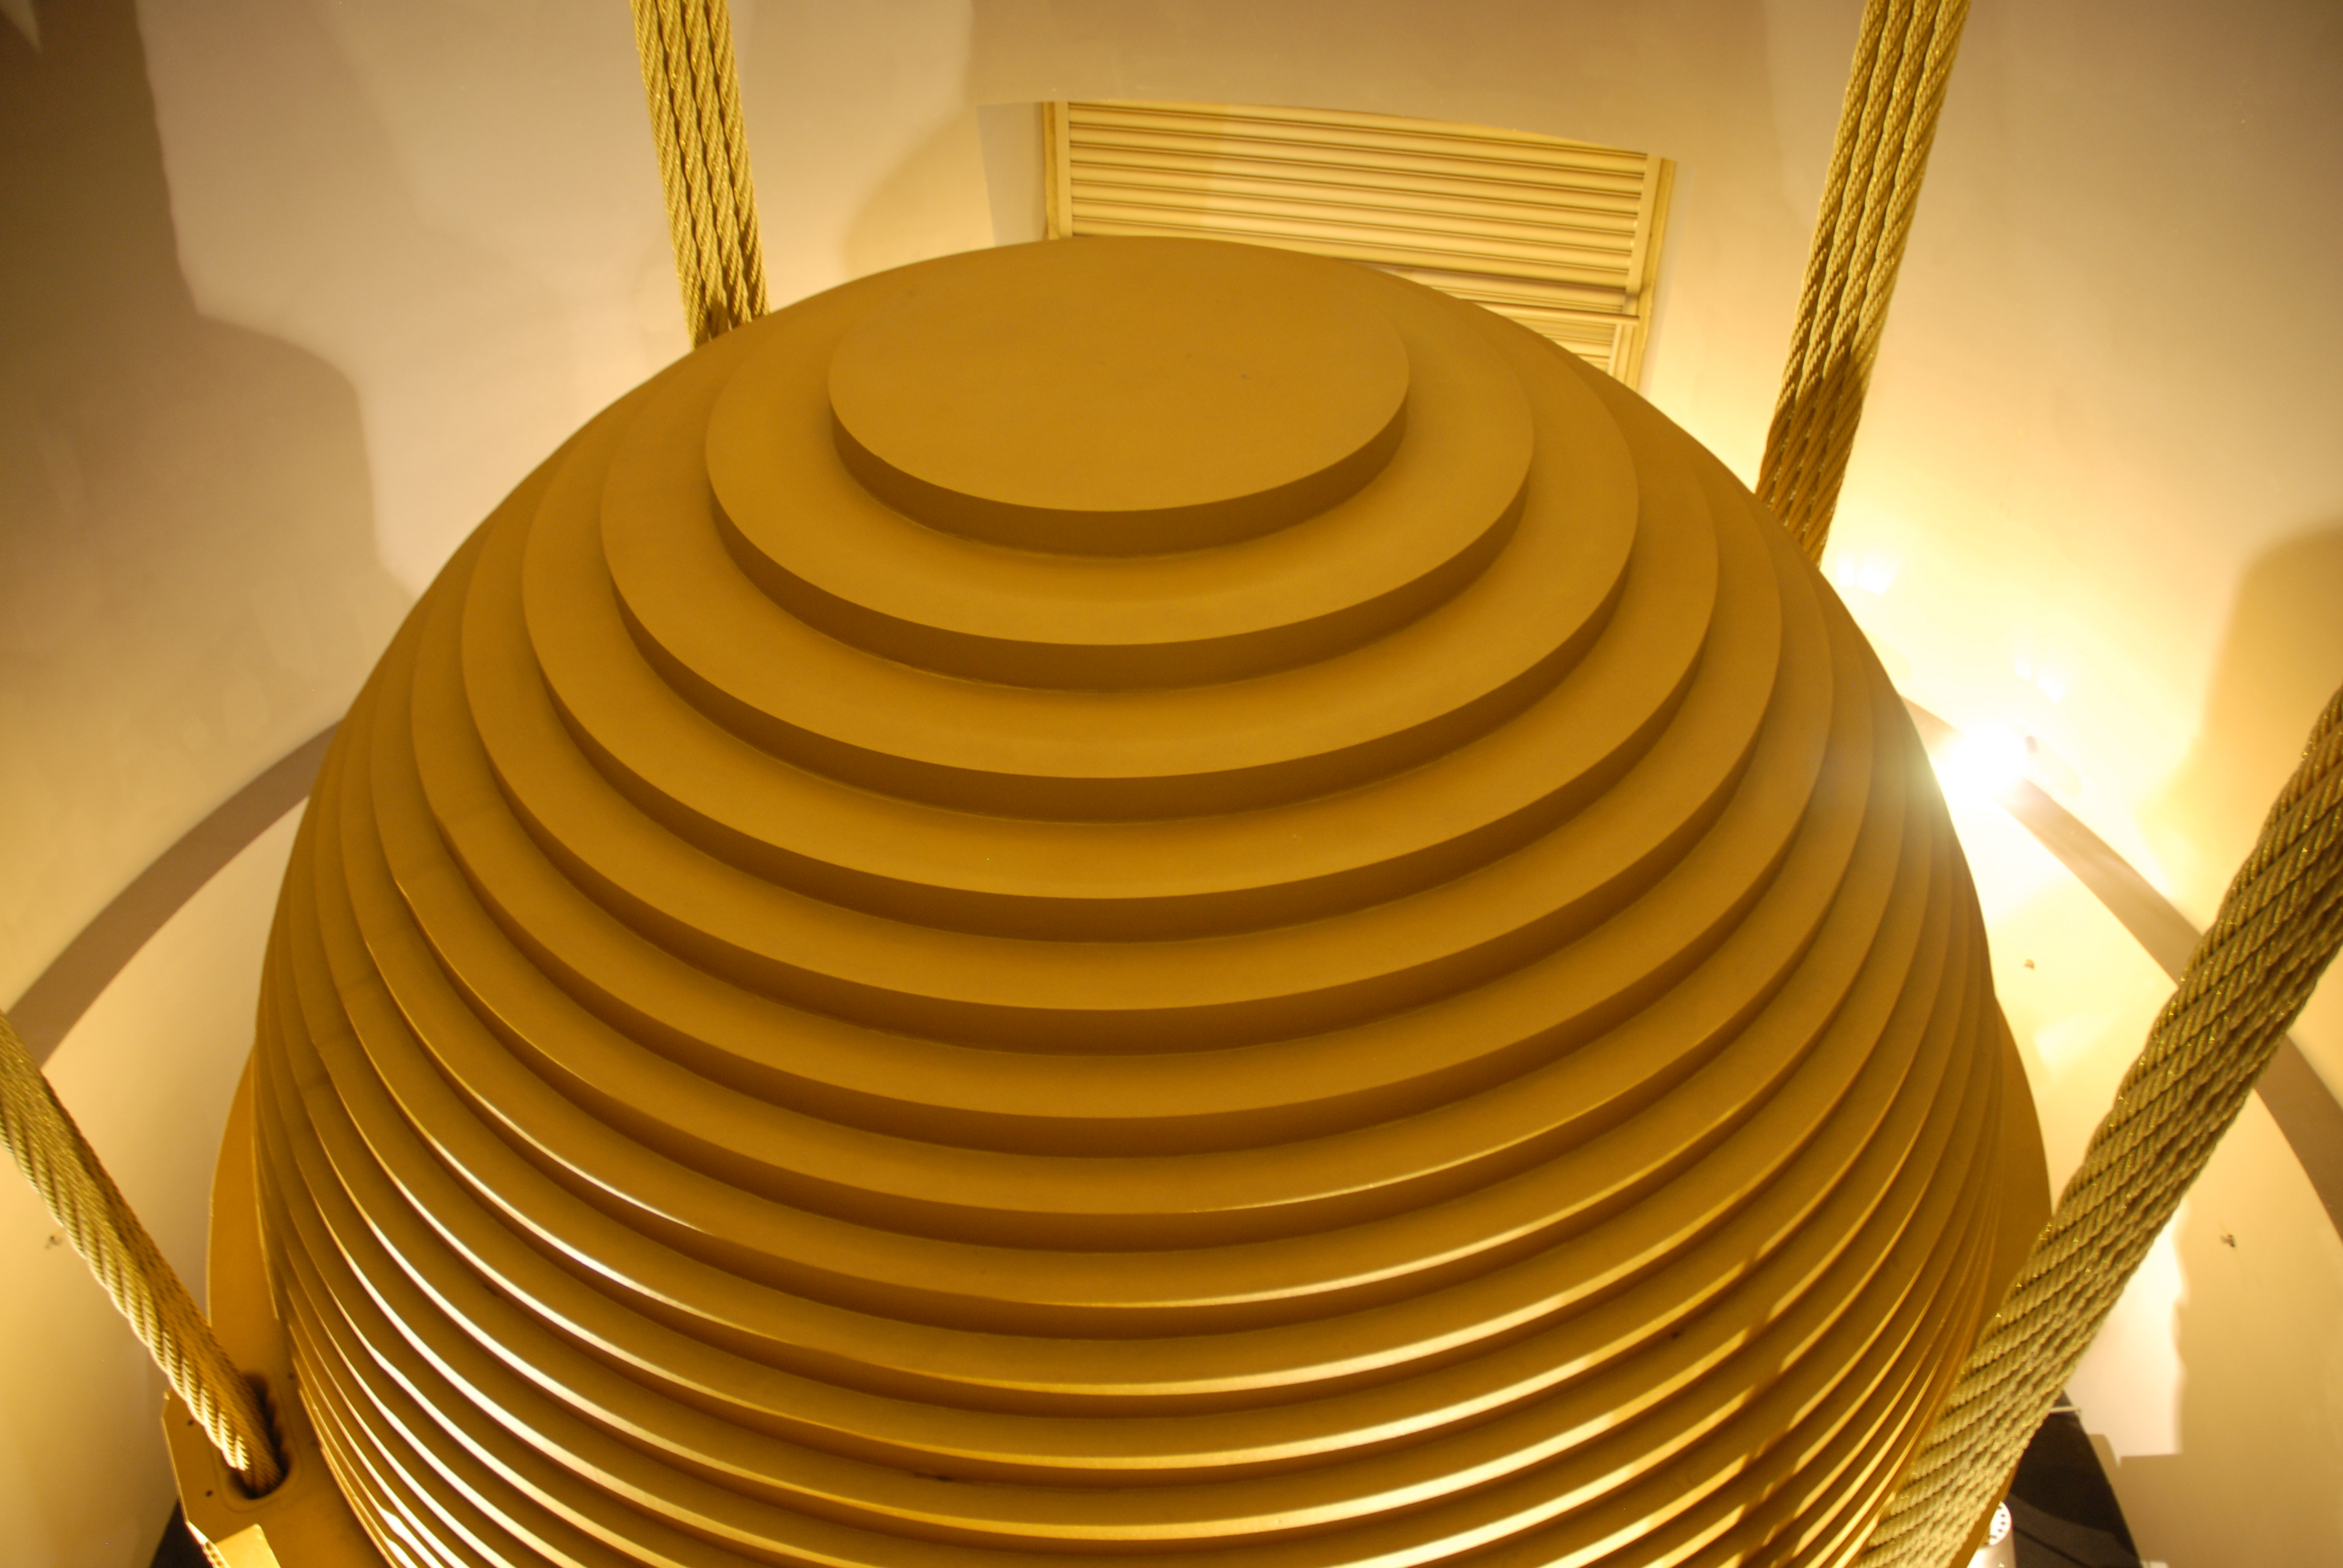
[Fuente](https://en.wikipedia.org/wiki/Tuned_mass_damper)

Entonces lo que podemos hacer es modelar el carrito y el pendulo por aparte, y facilitar el análisis mediante un análisis de energías y usando un esquema de movimiento global para determinar la cinemática del problema en un marco general así:
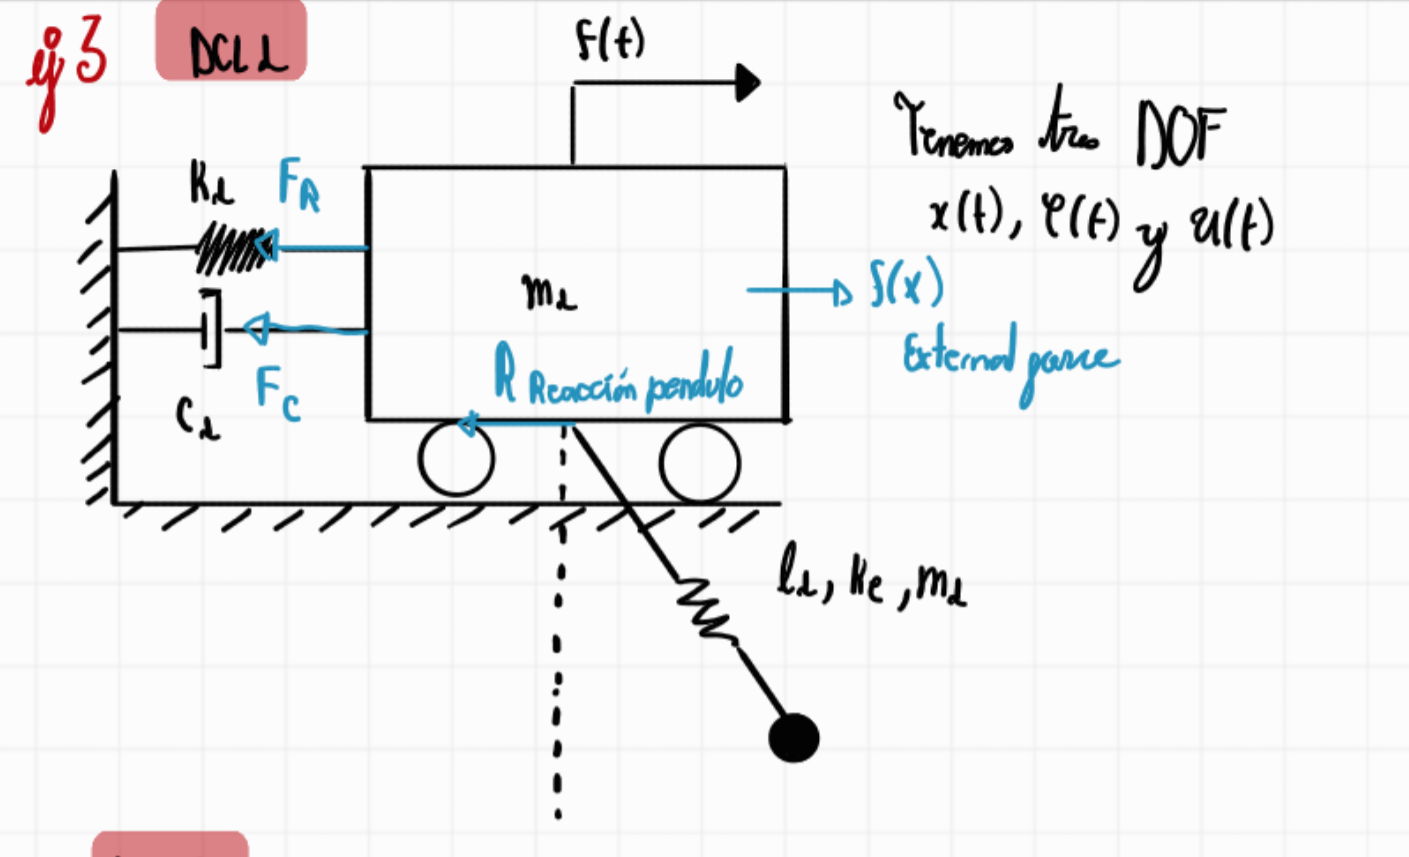
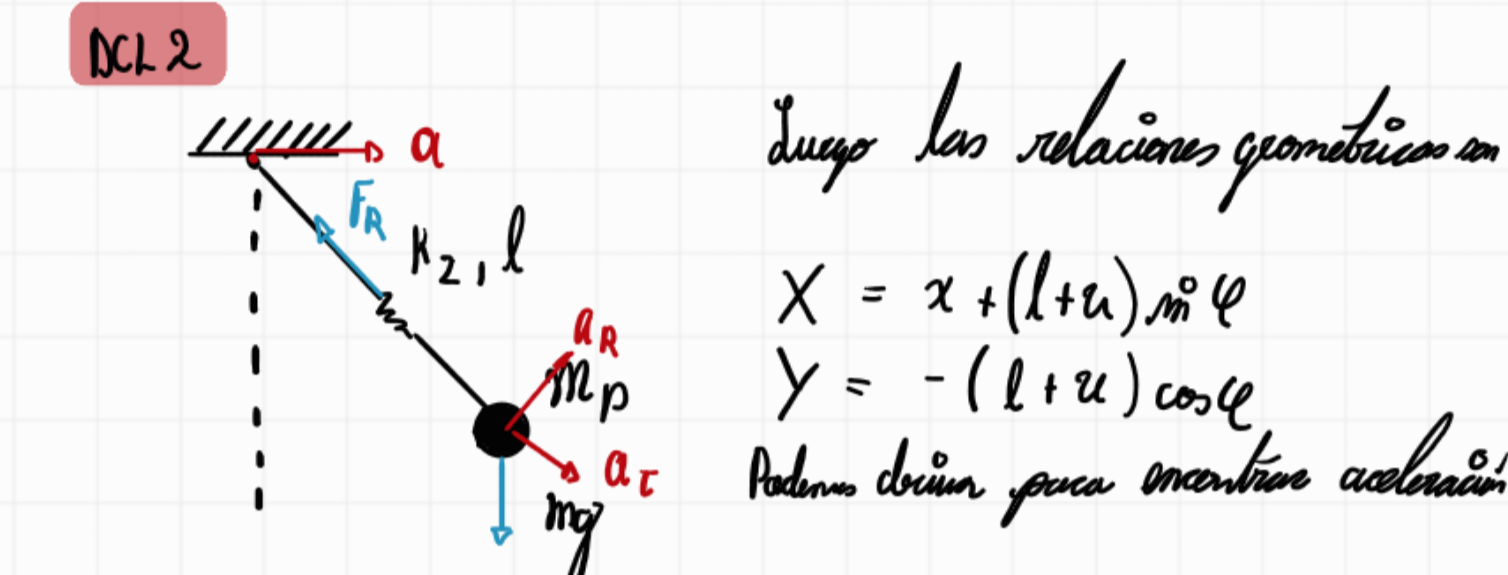
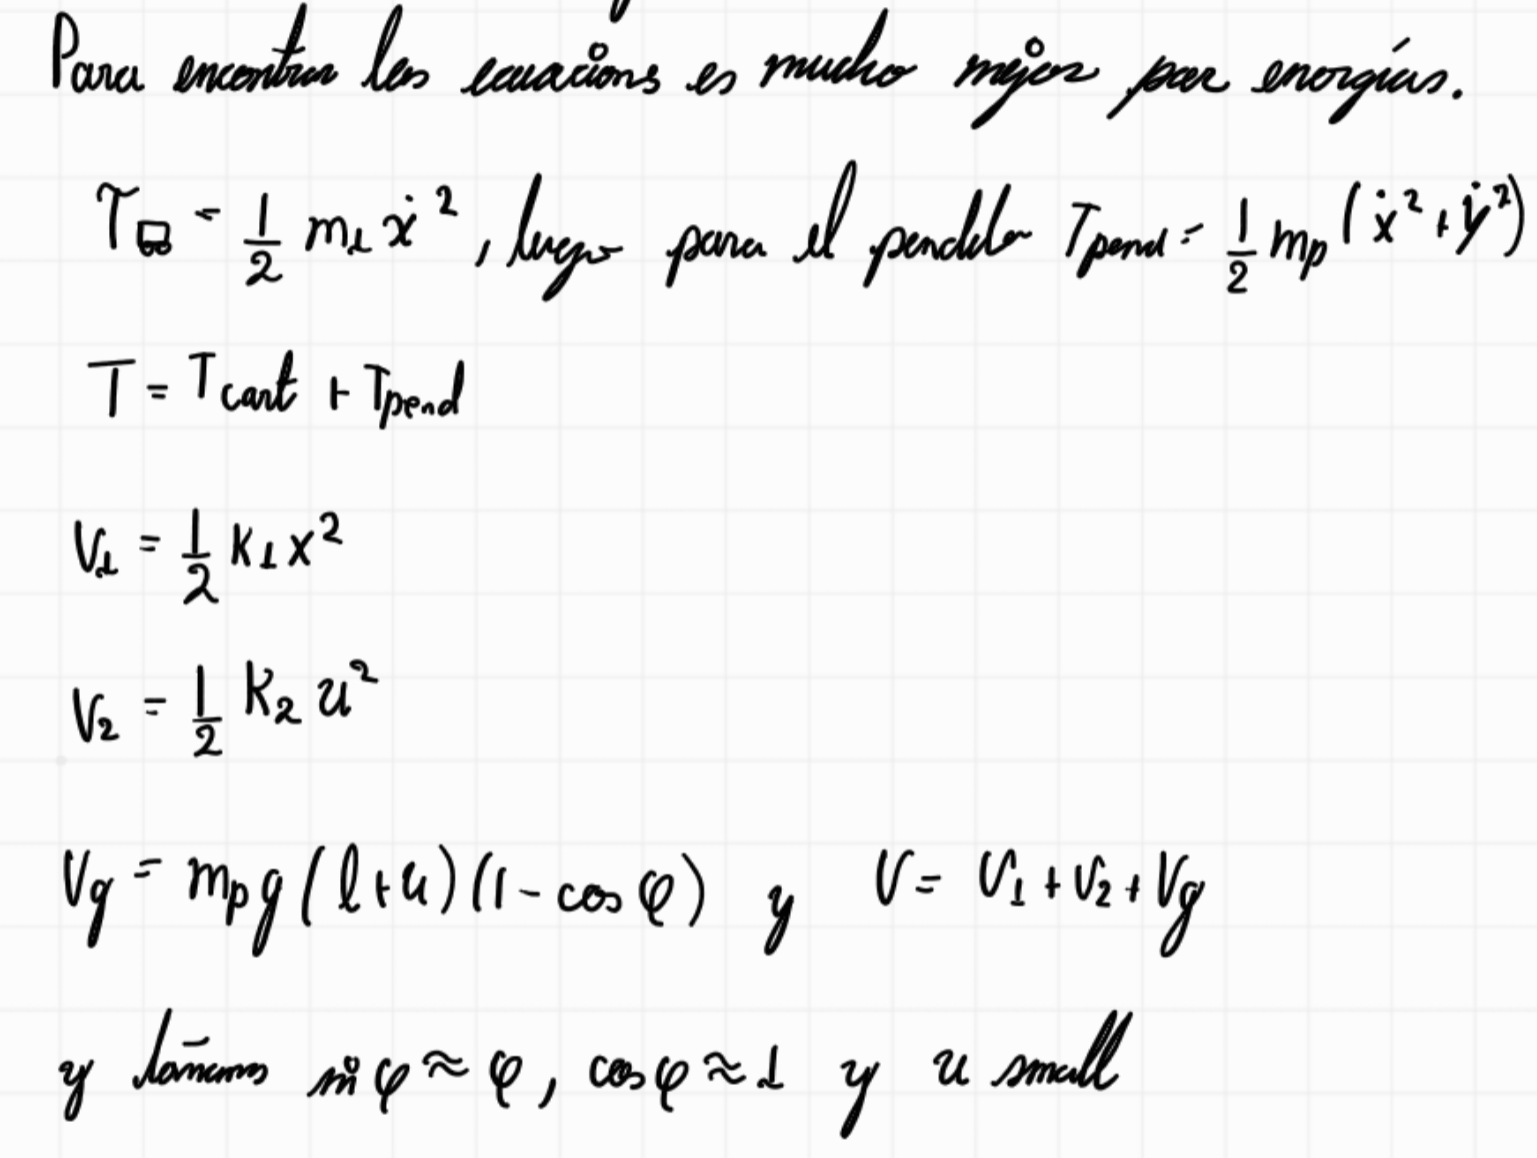
Investigando un poco más, este tipo de analisis ya esta desarollado con sistemas de dampening más modernos que usan precisamente masas tendidas para constrarestar efectos ocilatorios de altas magnitudes.
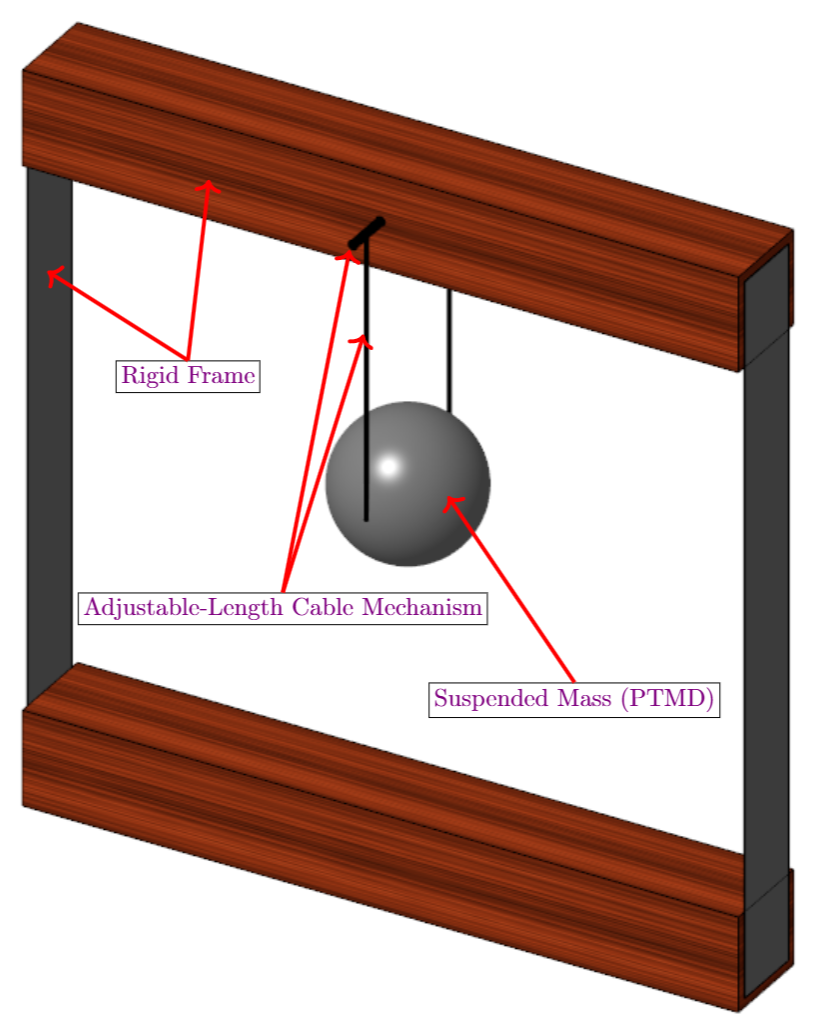 

Luego encontre estos dos papers que buscan modelar precisamente el sistema que estamos intentando en este ejercicio:
* https://www.mdpi.com/2071-1050/17/14/6301
* https://www.researchgate.net/publication/329311552_Numerical_evaluation_of_the_effect_of_Combined_Pendulum_Tuned_Mass_Damper_on_a_basic_vibrating_system
Entonces la idea es intentar recrear estos resultados que ellos obtienen a ver si se puede lograr el python, pues ellos utilizaron simulink y el otro paper creo que utilizo un método numerico diferente.

In [7]:

# dynamic symbols
t = symbols('t')
x, phi, u = dynamicsymbols('x phi u')   # generalized coordinates as functions of time
f_ext = dynamicsymbols('f')             # external forcing f(t)

# parameters (constants)
m1, mp, k1, ke, ell, c1, g = symbols('m1 mp k1 ke ell c1 g')

# Define pendulum length and bob position (inertial frame)
L = ell + u
X = x + L * sin(phi)
Y = - L * cos(phi)

# Velocities
Xd = diff(X, t)
Yd = diff(Y, t)
xd = diff(x, t)
phid = diff(phi, t)
ud = diff(u, t)

# Kinetic energies
T_cart = (m1*xd**2)/2
T_pend = (mp*(Xd**2 + Yd**2))/2
T = simplify(T_cart + T_pend)

# Potential energies
V_cart = (k1*x**2)/2
V_elastic = (ke*u**2)/2
V_grav = mp*g*(L*(1 - cos(phi)))
V = simplify(V_cart + V_elastic + V_grav)

# Lagrangian
Lagr = simplify(T - V)

# Generalized non-conservative forces
Qx = f_ext - c1*xd
Qphi = 0
Qu = 0

# Euler-Lagrange operator
def EL(Lagr, q):
    qd = diff(q, t)
    dL_dqd = diff(Lagr, qd)
    d_dt_dL_dqd = diff(dL_dqd, t)
    dL_dq = diff(Lagr, q)
    return simplify(d_dt_dL_dqd - dL_dq)

EL_x = EL(Lagr, x) - Qx
EL_phi = EL(Lagr, phi) - Qphi
EL_u = EL(Lagr, u) - Qu

# Replace second derivatives by symbols so we can solve algebraically
ddx, ddphi, ddu = symbols('ddx ddphi ddu')  # placeholders for second derivatives
repl = {
    diff(x, t, 2): ddx,
    diff(phi, t, 2): ddphi,
    diff(u, t, 2): ddu
}
# Also keep first derivatives as symbols for clarity
vx, vphi, vu = symbols('vx vphi vu')
repl_first = {
    diff(x, t): vx,
    diff(phi, t): vphi,
    diff(u, t): vu
}

ELx_lin = simplify(EL_x.xreplace(repl_first).xreplace(repl))
ELphi_lin = simplify(EL_phi.xreplace(repl_first).xreplace(repl))
ELu_lin = simplify(EL_u.xreplace(repl_first).xreplace(repl))

# Solve linear system for ddx, ddphi, ddu
sol = solve([ELx_lin, ELphi_lin, ELu_lin], (ddx, ddphi, ddu), dict=True)

# Present solutions
print("Solved accelerations (second derivatives) in terms of states and parameters:\n")
if sol:
    sol0 = {k: simplify(v) for k, v in sol[0].items()}
    print("ddx =")
    display(sol0[ddx])
    print("\n\nddphi =")
    display(sol0[ddphi])
    print("\n\nddu =")
    display(sol0[ddu])
    # Also print LaTeX for easy copy-paste
    print("\n\nLaTeX forms:\n")
    print("ddx:\n", latex(sol0[ddx]))
    print("\n\nddphi:\n", latex(sol0[ddphi]))
    print("\n\nddu:\n", latex(sol0[ddu]))
else:
    print("Could not solve algebraically for accelerations. Here are the raw EL equations:")
    display(EL_x)
    display(EL_phi)
    display(EL_u)

Solved accelerations (second derivatives) in terms of states and parameters:

ddx =


-c₁⋅vx + g⋅mp⋅sin(φ) - k₁⋅x + ke⋅u⋅sin(φ) + f
─────────────────────────────────────────────
                     m₁                      



ddphi =


                             g⋅mp⋅sin(2⋅φ)                 ke⋅u⋅sin(2⋅φ)       ↪
c₁⋅vx⋅cos(φ) - g⋅m₁⋅sin(φ) - ───────────── + k₁⋅x⋅cos(φ) - ───────────── - 2⋅m ↪
                                   2                             2             ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                           m₁⋅(ell + u)                        ↪

↪                     
↪ ₁⋅vphi⋅vu - f⋅cos(φ)
↪                     
↪ ────────────────────
↪                     



ddu =


                                                  2                            ↪
c₁⋅vx⋅sin(φ)           2                  g⋅mp⋅sin (φ)   k₁⋅x⋅sin(φ)   ke⋅u    ↪
──────────── + ell⋅vphi  + g⋅cos(φ) - g - ──────────── + ─────────── - ──── -  ↪
     m₁                                        m₁            m₁         mp     ↪

↪         2                        
↪ ke⋅u⋅sin (φ)       2     f⋅sin(φ)
↪ ──────────── + vphi ⋅u - ────────
↪      m₁                     m₁   



LaTeX forms:

ddx:
 \frac{- c_{1} vx + g mp \sin{\left(\phi{\left(t \right)} \right)} - k_{1} x{\left(t \right)} + ke u{\left(t \right)} \sin{\left(\phi{\left(t \right)} \right)} + f{\left(t \right)}}{m_{1}}


ddphi:
 \frac{c_{1} vx \cos{\left(\phi{\left(t \right)} \right)} - g m_{1} \sin{\left(\phi{\left(t \right)} \right)} - \frac{g mp \sin{\left(2 \phi{\left(t \right)} \right)}}{2} + k_{1} x{\left(t \right)} \cos{\left(\phi{\left(t \right)} \right)} - \frac{ke u{\left(t \right)} \sin{\left(2 \phi{\left(t \right)} \right)}}{2} - 2 m_{1} vphi vu - f{\left(t \right)} \cos{\left(\phi{\left(t \right)} \right)}}{m_{1} \left(\ell + u{\left(t \right)}\right)}


ddu:
 \frac{c_{1} vx \sin{\left(\phi{\left(t \right)} \right)}}{m_{1}} + \ell vphi^{2} + g \cos{\left(\phi{\left(t \right)} \right)} - g - \frac{g mp \sin^{2}{\left(\phi{\left(t \right)} \right)}}{m_{1}} + \frac{k_{1} x{\left(t \right)} \sin{\left(\phi{\left(t \right)} \right)}}{m_{1}} - \frac{ke u{\left(t \right)}}{mp} - \frac{ke 

Esta primera aproximación nos da tres ecuaciones diferenciales de la forma:
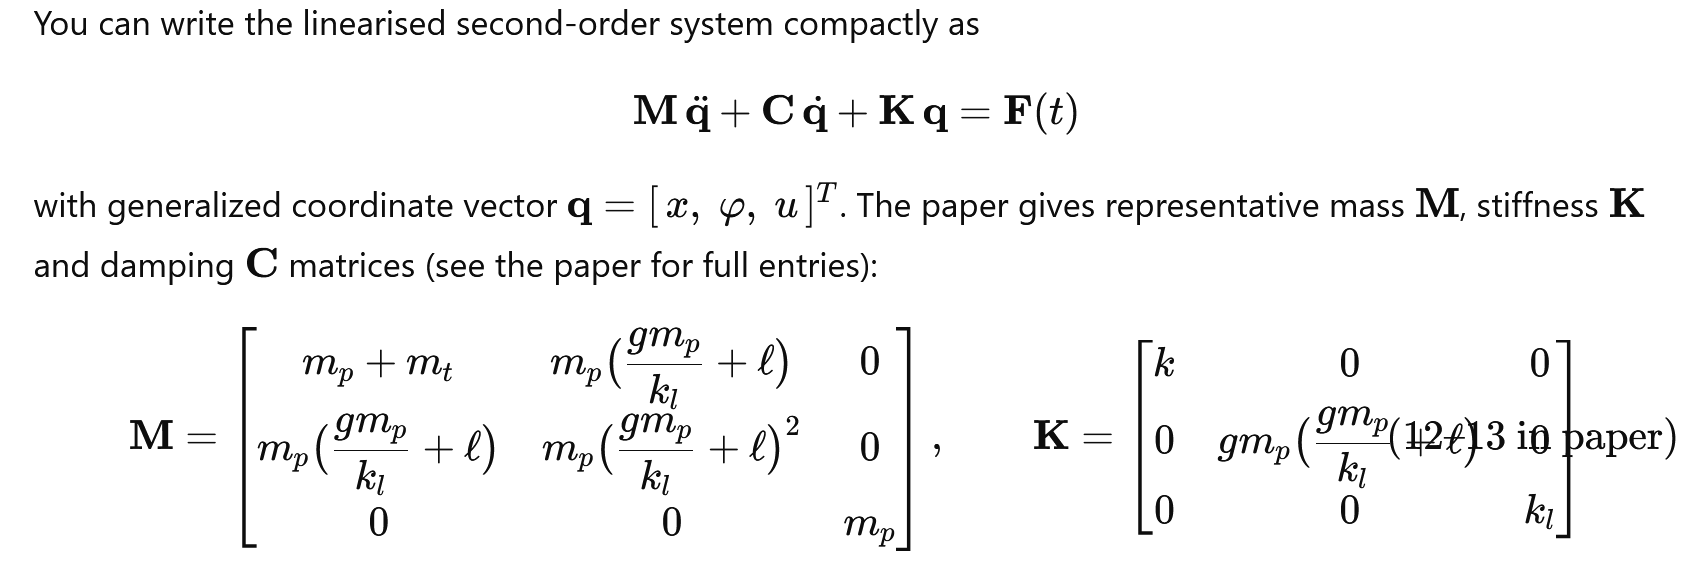
Este sistema de ecuaciones diferenciales es parecido al que obtienen en uno de los dos papers que mencione:
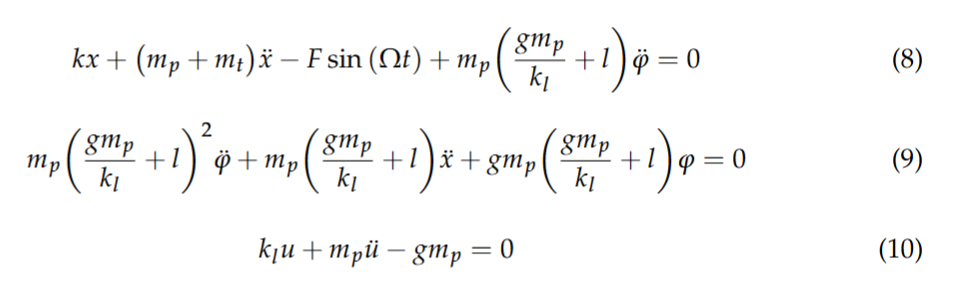

Entonces podemos utilizar este sistema para intentar simular el movimiento de nuestro sistema en diferentes configuraciones, de hecho el segundo
paper que adjunto hace esto para encontrar combinaciones optimas para diferentes casos de uso:
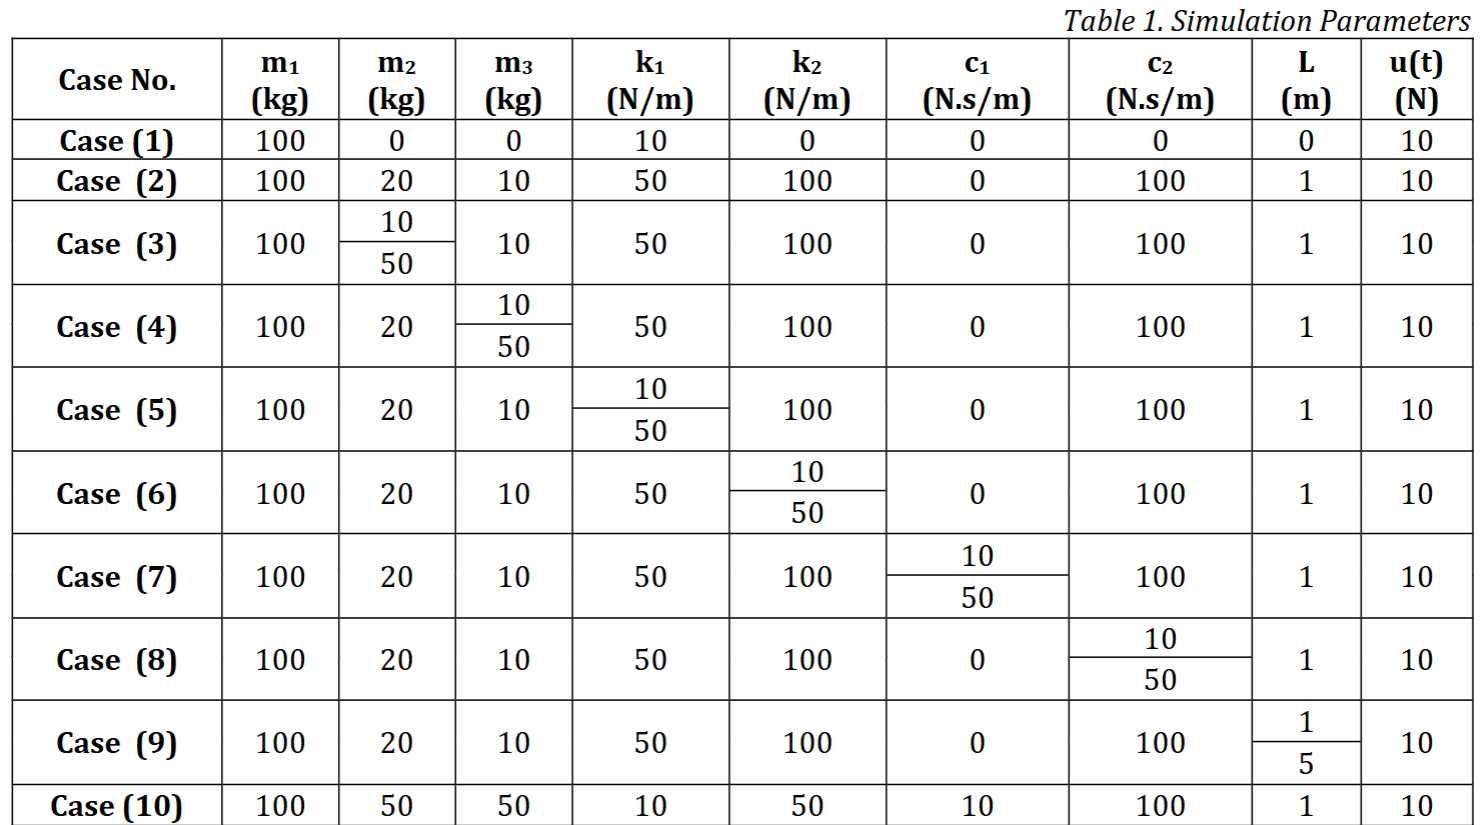

Entonces intentare recrear algunas de estas configuraciones pero tomando algunas simplificaciones adicionales.
1. Podemos asumir que el grado de libertad adicional que agrega u(t) no es lo suficientemente significativo para hacer una diferencia en la dinamica general del problema, de hecho dado una masa suficientemente grande y asumiendo un comportamiento en grados pequeños podemos simplificar este grado y obtener unas soluciones más sencillas, nos reducimos de un sistema 3x3 a únicamente un sistema 2x2. Este queda así:
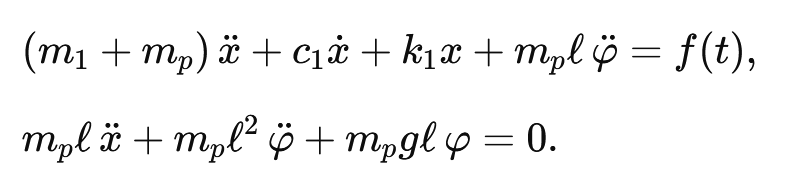
(Ecuaciones generadas por ChatGPT5, ahora las hago simbolicas para poder usarlas y simular el comportamiento)

Para esto hacemos la siguientes aproximaciones puntuales:
1. Vamos a tomar angulos pequeños de φ (φ≪1)
2. Tomaremos una elongación pequeña u≈0, lo cual sería equivalente a suponer un cuerpo rígido como el péndulo. Y como sinφ≈φ, cosφ≈1 obtenemos el modelo 2DOF lineal.

In [8]:
from sympy import symbols, Matrix, sin, cos, diff, simplify
from sympy.physics.vector import dynamicsymbols

# VARIABLES
t = symbols('t')
x, phi = dynamicsymbols('x phi')
m1, mp, k1, ell, c1, g = symbols('m1 mp k1 ell c1 g')
f = dynamicsymbols('f')

# VELOCIDADES
xd = diff(x, t)
phid = diff(phi, t)

# ENERGÍA CINÉTICA (linealizada)
T = (m1+mp)/2 * xd**2 + (mp*ell**2)/2 * phid**2 + mp*ell*xd*phid

# ENERGÍA POTENCIAL (linealizada)
V = k1*x**2/2 + mp*g*ell*phi**2/2

# LAGRANGIANO
L = T - V

# LAGRANGE OPERATOR
def EL(q):
    dq = diff(q,t)
    return simplify(diff(diff(L,dq),t) - diff(L,q))

EL_x  = simplify(EL(x)  - (f - c1*xd))
EL_phi = simplify(EL(phi))

# NUEVAS VARIABLES PARA SOLVER
ddx, ddphi = symbols('ddx ddphi')
vx, vphi = symbols('vx vphi')

subs = {
    diff(x,t): vx,
    diff(phi,t): vphi,
    diff(x,t,2): ddx,
    diff(phi,t,2): ddphi
}

eq1 = EL_x.subs(subs)
eq2 = EL_phi.subs(subs)

sol = solve([eq1, eq2], (ddx, ddphi), dict=True)[0]

ddx_expr = simplify(sol[ddx])
ddphi_expr = simplify(sol[ddphi])

display("ddx =", ddx_expr)
display("ddphi =", ddphi_expr)

'ddx ='

-c₁⋅vx + g⋅mp⋅φ - k₁⋅x + f
──────────────────────────
            m₁            

'ddphi ='

c₁⋅vx - g⋅m₁⋅φ - g⋅mp⋅φ + k₁⋅x - f
──────────────────────────────────
              ell⋅m₁              

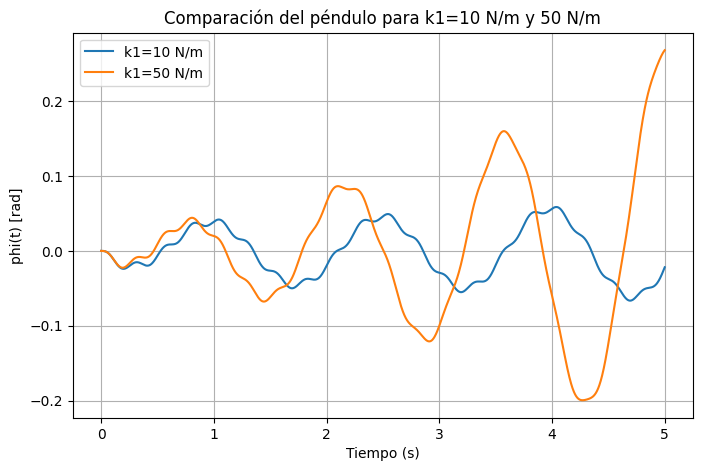

k1=10: max |phi| = 0.0663 rad
k1=50: max |phi| = 0.2676 rad


In [9]:
# PARAMETROS
m1 = 2.0
mp = 0.5
ell = 0.5
c1 = 4.5
g = 9.81

def forcing(t):
    return 8*np.sin(2*np.pi*4*t)

# ECUACIONES DIFERENCIALES
def rhs(t, y, k1):
    x, vx, phi, vphi = y

    ddx = (-c1*vx - k1*x - mp*g*phi + forcing(t)) / (m1+mp)
    ddphi = -(g*phi + ell*ddx) / ell

    return [vx, ddx, vphi, ddphi]

# SIMULACIÓN
t_eval = np.linspace(0, 5, 2000)
y0 = [0, 0, 0, 0]

k_values = [10, 50]
results = {}

for k1 in k_values:
    sol = solve_ivp(lambda t,y: rhs(t,y,k1), [0,5], y0, t_eval=t_eval)
    results[k1] = sol

# GRAFICAR
plt.figure(figsize=(8,5))
for k1, sol in results.items():
    plt.plot(sol.t, sol.y[2], label=f"k1={k1} N/m")

plt.xlabel("Tiempo (s)")
plt.ylabel("phi(t) [rad]")
plt.title("Comparación del péndulo para k1=10 N/m y 50 N/m")
plt.grid(True)
plt.legend()
plt.show()

# IMPRIMIR AMPLITUD
for k1, sol in results.items():
    print(f"k1={k1}: max |phi| = {np.max(np.abs(sol.y[2])):.4f} rad")


Ahora claro, el problema es que este modelamiento no tiene en cuenta el efecto del ke dentro del movimiento, y al hacer estas aproximaciones solo tiene sentido en cambios muy pequeños de phi, entonces ahora emplementemos el otro modelo que describe mejor la situación física... pero implica una matriz de 3x3. (Además que puedo entender como llegan al sistema 2x2 y como lo pasan por la transformada, pero el sistema 3x3 no tengo intuición alguna.)

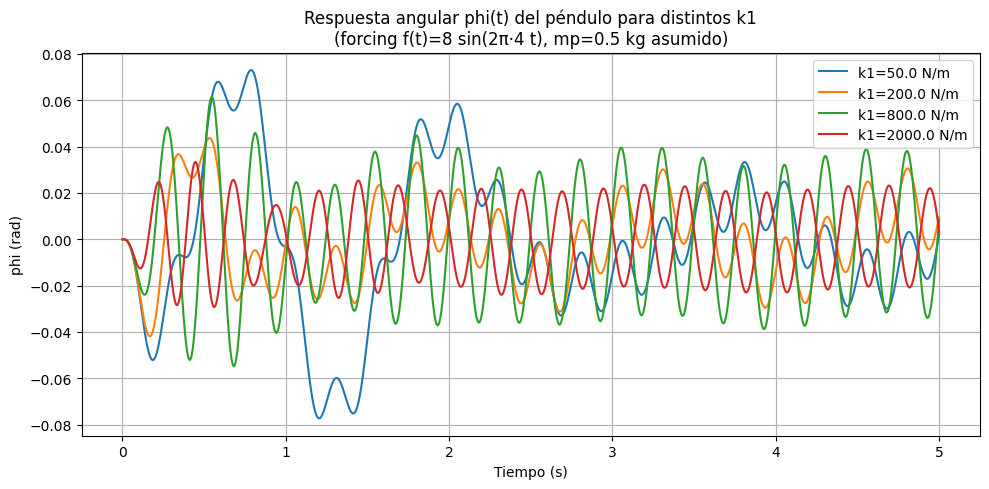

In [10]:
# Simulación y análisis del modelo linealizado 3x3 (carrito + péndulo elástico axial)
# Se parte de la aproximación de ángulos pequeños (sin(phi)≈phi, cos(phi)≈1 - phi^2/2)
# y se obtienen las ecuaciones lineales con parámetros numéricos dados.
# Resultado: se integra numéricamente y se grafica phi(t) para varios valores de k1.
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- Parámetros (valores proporcionados por el usuario) ---
m1 = 2.0      # masa del carrito (kg) (m1 dado)
mp = 0.5      # masa del péndulo (kg) -> **asunción** (no proporcionada por el usuario)
ke = 750.0    # constante elástica del péndulo (N/m)
l1 = 0.5      # longitud en equilibrio (m)
c1 = 4.5      # amortiguamiento del carrito (Ns/m)
g = 9.81      # gravedad (m/s^2)

# Forcing f(t) = 8 * sin(2*pi*4*t)
A = 8.0
omega_f = 2 * np.pi * 4.0

# Valores de k1 (rigidez del soporte) para comparar
k1_list = [50.0, 200.0, 800.0, 2000.0]

# Tiempo de simulación
t0, tf = 0.0, 5.0   # segundos
t_eval = np.linspace(t0, tf, 3001)

# Construcción de matrices para el sistema linealizado (en variables x, phi, u)
# Linearización (ángulos pequeños):
# Aproximaciones usadas en el Lagrangiano linealizado:
# X ≈ x + l1*phi  -> Xdot ≈ xdot + l1*phidot
# Y vertical contributions give gravitational stiffness for phi: mp*g*l1*phi^2/2 -> leads to term mp*g*l1*phi in EL
# Kinetic energies lead to coupling between x and phi via mp*l1
#
# Ecuaciones lineales (en forma matricial M * q_dd + C * q_d + K * q = F)
# q = [x, phi, u]

def build_matrices(k1):
    # Masa (M)
    M = np.zeros((3,3))
    M[0,0] = m1 + mp           # carrito + parte translacional del péndulo
    M[0,1] = mp * l1           # coupling due to pendulum horizontal motion
    M[1,0] = mp * l1
    M[1,1] = mp * l1**2        # pendulum rotational inertia (linearized)
    M[2,2] = mp                # axial mass for u (pendulum bob axial motion)
    # Amortiguamiento (C)
    C = np.zeros((3,3))
    C[0,0] = c1
    # Rigidez (K)
    K = np.zeros((3,3))
    K[0,0] = k1
    K[0,1] = 0.0
    K[1,1] = mp * g * l1       # gravity provides restoring torque for small phi
    K[2,2] = ke
    # Note: cross K terms between u and phi or x are neglected in first-order linear approx
    # (they would be of smaller order or appear if including mp*g*u or coupling mp*l1*u*phi)
    return M, C, K

# Función que integra el sistema M q_dd + C q_d + K q = F (F = [f(t), 0, 0])
def simulate_for_k(k1):
    M, C, K = build_matrices(k1)
    Minv = np.linalg.inv(M)

    def rhs(t, y):
        # y = [x, phi, u, xdot, phidot, udot]
        q = y[:3]
        qd = y[3:]
        # Forcing only in x coordinate
        F = np.array([A * np.sin(omega_f * t), 0.0, 0.0])
        # compute accelerations: q_dd = Minv * (F - C qd - K q)
        qdd = Minv @ (F - C @ qd - K @ q)
        return np.concatenate([qd, qdd])

    # condiciones iniciales: todas cero
    y0 = np.zeros(6)
    sol = solve_ivp(rhs, (t0, tf), y0, t_eval=t_eval, rtol=1e-8, atol=1e-8)
    return sol

# Ejecutar simulaciones para cada k1
solutions = {}
for k1 in k1_list:
    solutions[k1] = simulate_for_k(k1)

# Graficar phi(t) (ángulo del péndulo) para los diferentes k1 en un solo gráfico
plt.figure(figsize=(10,5))
for k1 in k1_list:
    sol = solutions[k1]
    phi = sol.y[1]   # phi(t)
    plt.plot(sol.t, phi, label=f'k1={k1} N/m')
plt.xlabel('Tiempo (s)')
plt.ylabel('phi (rad)')
plt.title('Respuesta angular phi(t) del péndulo para distintos k1\n(forcing f(t)=8 sin(2π·4 t), mp=0.5 kg asumido)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Mostrar algunos indicadores: RMS y pico de phi en TF final
import pandas as pd
rows = []
for k1 in k1_list:
    phi = solutions[k1].y[1]
    rows.append({'k1 (N/m)': k1, 'phi_rms (rad)': np.sqrt(np.mean(phi**2)), 'phi_max (rad)': np.max(np.abs(phi))})



# Análisis


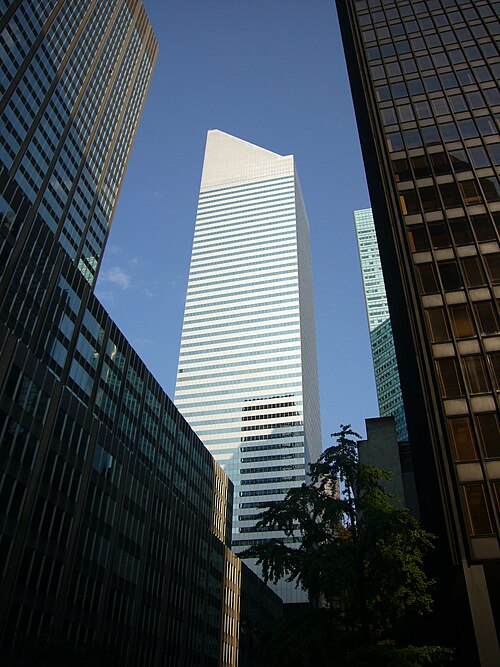

Investigando para este punto uno encuentra varias cosas curiosas.
Estos sistemas se usan ahora en muchos edificios alrededor del mundo, pero de las primeras implementaciones, de hecho la primera implementacion fue el edificio [Citycorp en New York](https://es.wikipedia.org/wiki/Citigroup_Center#Elementos_destacables) que fue de los primeros en tener este sistema, y de hecho este edificio es infame por una crisis de diseño que básicamente implicaba que este tuviera riesgo de caerse cada 55 años. Lo único que redujo este efecto fue precisamente el efecto del mass dampener, que básicamente en nuestra implementación reducia las oscilaciones del viento mediante la masa de péndulo. De hecho era tan efectivo que se le atribuye el hecho que Citycorp no terminara en un desastre de la ingeniería. (La razón por la cual fue necesario implemetar reparaciones y no solo depender del dampener es que este necesita mantener un suministro de energía para funcionar, esto no lo vimos en la implementación, y la verdad no se eso en que afecte nuestro modelo).

### Ej3b 
Para ke=750N/m, m1=2kg, l1=0.5m y c1=4.5Ns/m. Suponga que la fuerza f(t) tiene un
comportamiento senoidal f=8*sin(2*pi*4*t). Analice el efecto de k1 en el movimiento del
péndulo

# Ej4
(1.5 punto) El sistema presentado en la figura está compuesto por una polea de masa NO
DESPRECIABLE (mpolea), un resorte de rigidez k y una masa m, conectados por una cuerda
no deformable que nunca se desliza respecto a la polea. Puede calcular la inercia de la
polea como Icm=½ mpolea R 2

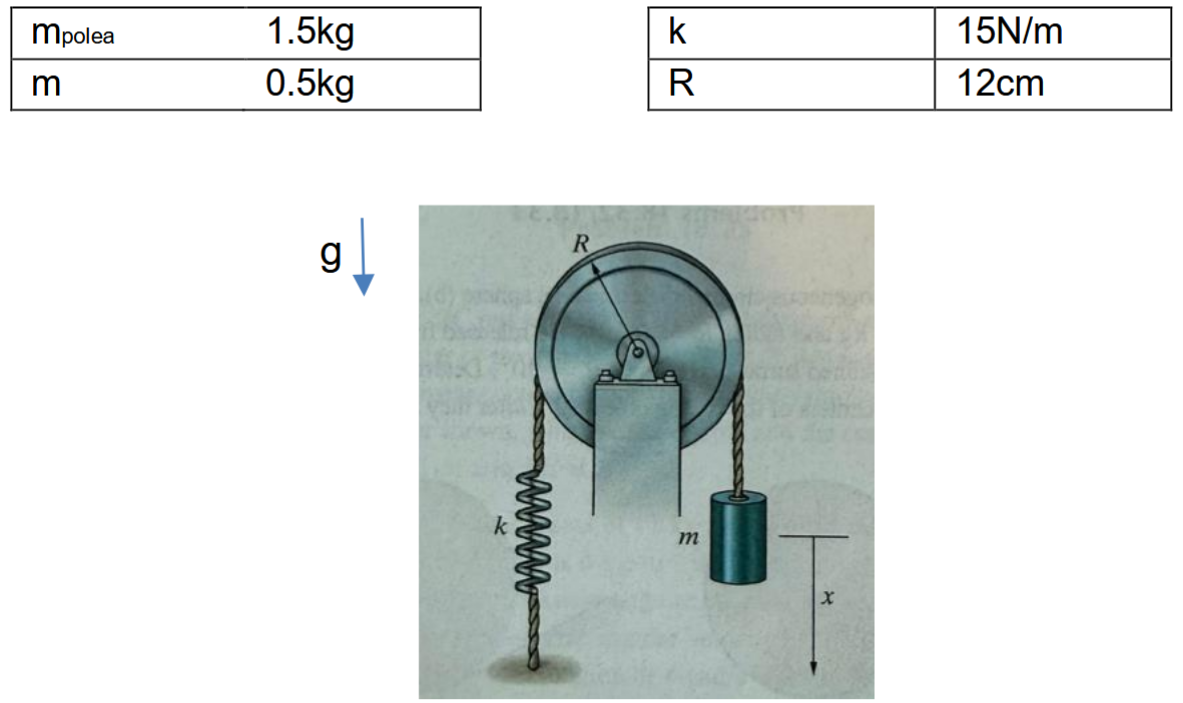

Encuentre el menor amortiguador posible que pueda poner en su sistema de forma que la
masa no presente oscilaciones luego de ser liberada desde x=0.2m

In [11]:
# símbolos
m, mp, R, k, g, x, xdd, wn = symbols('m mp R k g x xdd wn')

# inercia
I = mp*R**2/2

# tensiones
T_right = m*g - m*xdd
T_left  = k*x

# torque
eq = Eq(I*(xdd/R), R*(T_right - T_left))

# dinámica
dyn = simplify(eq.lhs - eq.rhs)
dyn = Eq((m + mp/2)*xdd + k*x - m*g, 0)

# equilibrio
x_eq = solve(Eq(k*x - m*g, 0), x)[0]

# frecuencia natural
eq_wn = Eq(wn**2, k/(m + mp/2))
sol_wn = solve(eq_wn, wn)

# valores numéricos
vals = {m:0.5, mp:1.5, R:0.12, k:15, g:9.81}

# aplicar sustitución primero
sol_num = [s.subs(vals) for s in sol_wn]

# ahora sí escoger la raíz positiva
wn_val = [s for s in sol_num if s > 0][0]

# frecuencia
f_val = wn_val/(2*pi)

display(wn_val)
display(f_val)

display(wn_val.evalf())
display(f_val.evalf())


0.632455532033676⋅√30

0.316227766016838⋅√30
─────────────────────
          π          

3.46410161513775

0.551328895421792

In [12]:
# símbolos
c, m, mp, R, k = symbols('c m mp R k', positive=True)

# masa equivalente del sistema
m_eq = m + mp/2

# amortiguamiento crítico
c_crit = 2*sqrt(k*m_eq)

# sustituir valores
vals = {m:0.5, mp:1.5, R:0.12, k:15}
c_min = c_crit.subs(vals)

# mostrar resultados simbólico y numérico
display(c_crit)
display(c_min)
display(c_min.evalf())


         ________
        ╱     mp 
2⋅√k⋅  ╱  m + ── 
     ╲╱       2  

2.23606797749979⋅√15

8.66025403784439